In [1]:
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

In [58]:
class InvertedPendulum(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(self, g=9.81, l=1.0, m=1.0, u_max=2.0, d_max=0.0, control_mode="max", disturbance_mode="min"):
        self.g = g
        self.l = l
        self.m = m

        control_space = hj.sets.Box(lo=jnp.array([-u_max]), hi=jnp.array([u_max]))
        disturbance_space = hj.sets.Box(lo=jnp.array([-d_max]), hi=jnp.array([d_max]))

        super().__init__(control_mode=control_mode, disturbance_mode=disturbance_mode, control_space=control_space, disturbance_space=disturbance_space)

    # omega = g/l * sin(theta)
    def open_loop_dynamics(self, state, time):
        theta, omega = state[..., 0], state[..., 1]
        theta_dot = omega
        omega_dot = -(self.g/self.l)*jnp.sin(theta) # negative makes it normal pendulum - not inverted
        return jnp.stack([theta_dot, omega_dot], axis=-1)

    # u/(ml^2)
    def control_jacobian(self, state, time):
        coeff = 1.0/(self.m*self.l**2)
        zeros = jnp.zeros_like(state[..., 0])
        J_c = jnp.stack([jnp.stack([zeros], axis=-1), jnp.stack([coeff + 0.0*zeros], axis=-1)], axis=-2)
        return J_c

    # + d
    def disturbance_jacobian(self, state, time):
        zeros = jnp.zeros_like(state[..., 0])
        J_d = jnp.stack([jnp.stack([zeros], axis=-1), jnp.stack([1.0+0.0*zeros], axis=-1)], axis=-2)
        return J_d

In [59]:
theta_min, theta_max = -np.pi, np.pi # boundary for the angle
omega_min, omega_max = -5.0, 5.0 # boundary for angular velocity

u_max = 2.0 # max control input
d_max = 0 # max disturbance

time = -3.0 # time of simulation
time_discretization = 201
grid_discretization = 201

times = np.linspace(0.0, time, time_discretization)
dynamics_attacker = InvertedPendulum(u_max=u_max, d_max=d_max)
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(hj.sets.Box(np.array([theta_min, omega_min]),np.array([theta_max, omega_max]),), shape=(grid_discretization, grid_discretization), periodic_dims=(0,))

theta_radius = 0.2
omega_radius = 0.2
theta = grid.states[..., 0]
omega = grid.states[..., 1]

In [ ]:
values0_attacker = (theta**2 / theta_radius**2) + (omega**2 / omega_radius**2) - 1.0 # ellipse: less than 1 is in the target set

solver_settings = hj.SolverSettings.with_accuracy("high")

value_function_attacker = hj.solve(solver_settings, dynamics_attacker, grid, times, values0_attacker)

  9%|##9                               |  0.2588/3.0 [00:00<00:05,  1.97s/sim_s]

In [ ]:
brs = np.array(value_function_attacker[0]) # brs at -T

plt.figure(figsize=(7,6))
cf = plt.contourf(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs.T, levels=60)
plt.contour(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs.T, levels=[0], colors="black", linewidths=2)
plt.xlabel("theta")
plt.ylabel("omega")
plt.colorbar(cf, label=f"V(theta, omega, {time})")
plt.title(f"BRS T={time}")
plt.show()

In [46]:
# take in a timestep query and the value function
# if the value function at timestep query and state value are less than 0
    # then that state will end up in the target set at time=0 after xthat many timesteps

# finding all the states that will end up in the target set after that many timesteps
    # even under the worst case disturbance with no control input

# optionally pass in a safe set if you only want to return starting states that actually start in safe set
def find_brs_at_timestep(timestep_query, value_function):
    brs_at_t = []
    values_at_t = []
    for theta in range(value_function.shape[1]): # iterate through first state
        for theta_dot in range(value_function.shape[2]): # iterate through next state
            for t in range(timestep_query + 1):
                if value_function[t, theta, theta_dot] >= 0:
                    break
                brs_at_t.append((theta, theta_dot))
                values_at_t.append(value_function[timestep_query, theta, theta_dot])
    return np.array(brs_at_t), np.array(values_at_t)

In [47]:
# takes in a brs which is represented as the indices of the states in the grid 
# outputs the actual corresponding state values
def find_states_in_brs(brs, grid):
    thetas, theta_dots = grid.coordinate_vectors
    thetas_brs = thetas[brs[:, 0]]
    theta_dots_brs = theta_dots[brs[:, 1]]
    return thetas_brs, theta_dots_brs

In [48]:
safe_set, safe_set_values = find_brs_at_timestep(timestep_query=0, value_function=value_function_attacker)
brs_3, brs_3_values = find_brs_at_timestep(3, value_function_attacker)

In [49]:
safe_set_states = find_states_in_brs(safe_set, grid)
brs_3_states = find_states_in_brs(brs_3, grid)

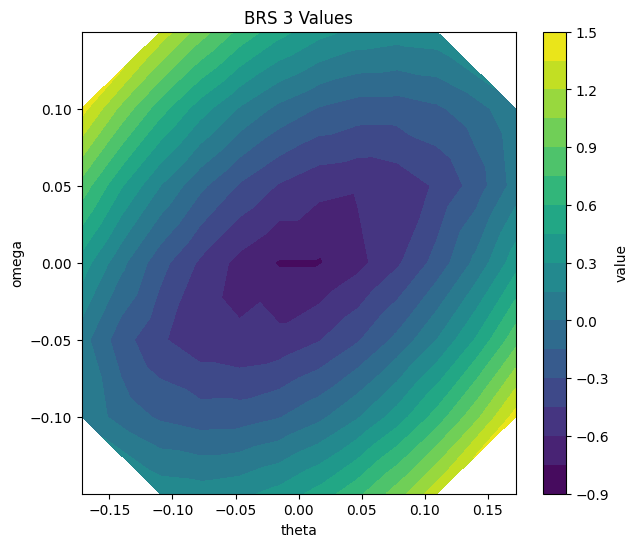

In [50]:
plt.figure(figsize=(7, 6))
cf = plt.tricontourf(brs_3_states[0], brs_3_states[1], brs_3_values, levels=20)
plt.colorbar(cf, label="value")
plt.xlabel("theta")
plt.ylabel("omega")
plt.title("BRS 3 Values")
plt.show()

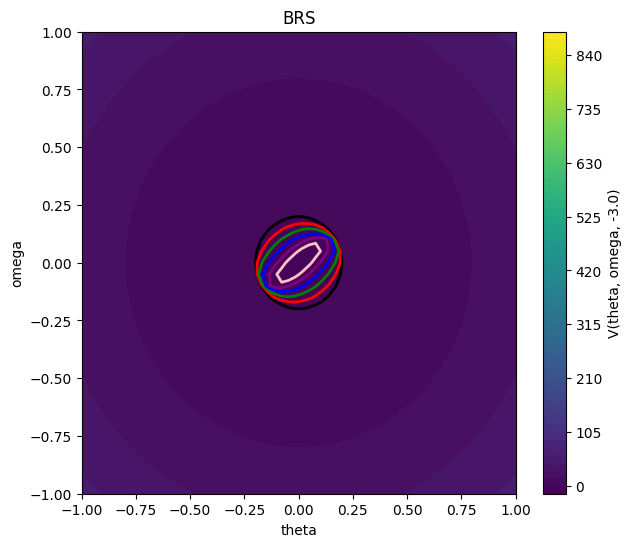

In [51]:
# plot the timestep layers 
v = np.array(value_function_attacker)
brs_0 = np.array(value_function_attacker[0]) 

plt.figure(figsize=(7,6))
cf = plt.contourf(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs_0.T, levels=60)
plt.contour(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs_0.T, levels=[0], colors="black", linewidths=2)

colors = ["red", "green", "blue", "purple", "pink", "orange"]
for i in range(1, 6):
    plt.contour(grid.coordinate_vectors[0], grid.coordinate_vectors[1], v[i].T, levels=[0], colors=colors[i-1], linewidths=2)

plt.xlabel("theta")
plt.ylabel("omega")
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.colorbar(cf, label=f"V(theta, omega, {time})")
plt.title(f"BRS")
plt.show()

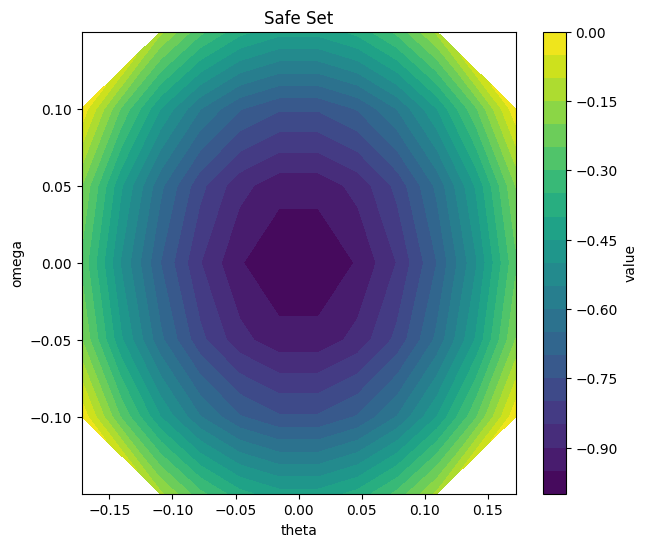

In [52]:
plt.figure(figsize=(7, 6))
cf = plt.tricontourf(safe_set_states[0], safe_set_states[1], safe_set_values, levels=20)
plt.colorbar(cf, label="value")
plt.xlabel("theta")
plt.ylabel("omega")
plt.title("Safe Set")
plt.show()

In [53]:
def compute_values0(brs_t, grid):
    # create a new distance function from all states to subset
    mask = np.zeros(grid.shape, dtype=bool)
    for idx in brs_t:
        mask[idx[0], idx[1]] = True
        
    dist_outside = distance_transform_edt(~mask, sampling=grid.spacings)
    dist_inside = distance_transform_edt(mask, sampling=grid.spacings)
    return dist_outside - dist_inside

In [54]:
def get_check_upper_bound(timestep_query, value_function_attacker, grid):
    # compute the inital target set
    safe_set, safe_set_values = find_brs_at_timestep(0, value_function_attacker)
    # compute the brs of timestep t
    brs_t, brs_t_values = find_brs_at_timestep(timestep_query, value_function_attacker)

    safe_mask = np.array(value_function_attacker[0]) < 0
    brs_t_mask = np.array(value_function_attacker[timestep_query]) < 0
    safe_minus_brs_t_mask = safe_mask & (~brs_t_mask)

    values0_controller = compute_values0(brs_t, grid)
    
    # do another reachability from all states to subset
    dynamics_controller = InvertedPendulum(u_max=u_max, d_max=d_max, control_mode="min", disturbance_mode="max")
    value_function_controller = hj.solve(solver_settings, dynamics_controller, grid, times, values0_controller)

    # compute the first timestep that becomes negative
    min_steps = []
    for (theta, theta_dot) in np.argwhere(safe_minus_brs_t_mask):
        for (t, v) in enumerate(value_function_controller[:, theta, theta_dot]):
            if v < 0:
                min_steps.append(t)
                break

    return max(min_steps) if len(min_steps) > 0 else None

In [55]:
results = [0]
for i in range(1, 7):
    results.append(get_check_upper_bound(i, value_function_attacker, grid))
print(results)

100%|##################################|  3.0000/3.0 [00:06<00:00,  2.04s/sim_s]
100%|##################################|  3.0000/3.0 [00:06<00:00,  2.01s/sim_s]
100%|##################################|  3.0000/3.0 [00:05<00:00,  1.90s/sim_s]
100%|##################################|  3.0000/3.0 [00:05<00:00,  1.69s/sim_s]
100%|##################################|  3.0000/3.0 [00:05<00:00,  1.91s/sim_s]
100%|##################################|  3.0000/3.0 [00:05<00:00,  1.96s/sim_s]


[0, 0, 0, 0, 0, 0, 0]


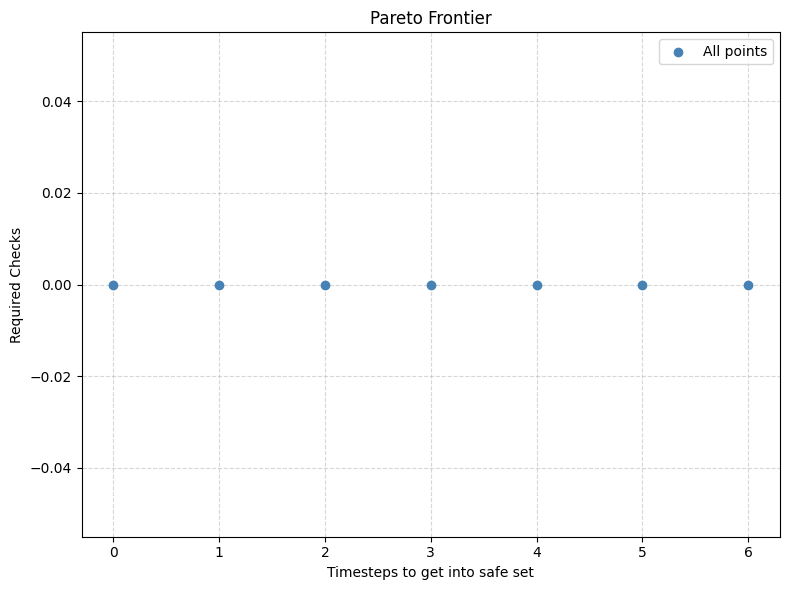

In [56]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(np.arange(7), results, color="steelblue", label="All points", zorder=3)

plt.title("Pareto Frontier")
plt.xlabel("Timesteps to get into safe set")
plt.ylabel("Required Checks")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()